# MAGZERO Measurement
Written by Kiyoaki Okudaira<br>
*Kyushu University Hanada Lab / University of Washington / IAU CPS SatHub<br>
(okudaira.kiyoaki.528@s.kyushu-u.ac.jp or kiyoaki@uw.edu)<br>
<br>
Measure zeropoint from a single frame image with multiple stars.<br>
<br>
**History**<br>
coding 2026-07-05 : 1st coding<br>
<br>
(c) 2026 Kiyoaki Okudaira - Kyushu University Hanada Lab (SSDL) / University of Washington / IAU CPS SatHub

### Parameters
**Plate solve settings**<br>
Exept special cases, follow default / recommended values

In [21]:
solve_downsample = 2    # Downsample the image by factor (recommend 2) | int
solve_source_obj = 100  # Cut the source list to have this many items (recommend 10) | int
solve_cat_radius = 1    # Only search within radius of the field center [deg] (recommend 1) | int

# Advanced
solve_no_removel = True # NOT remove horizontal and vertical overdensities of sources | bool
solve_tagallstar = True # Grab all tag-along columns from index into RDLS file (TRUE ANYTIME) | bool
solve_over_write = True # Overwrite output files if they already exist (TRUE ANYTIME) | bool
solve_uniformize = 10   # Select sources uniformly (0=disable; default 10) | int

**Measurement settings**

In [22]:
# aperture radius for star
aperture_radius = 24 # [pixel] | int or float

# aperture radius for background
annulus_r_in    = 30 # [pixel] | int or float
annulus_r_out   = 36 # [pixel] | int or float

# search size for star C.G.
box_size        = 63 # [pixel] | int and MUST BE ODD NUMBER
max_shift       = 16 # maximum modification of star position [pixel] | int or float

**MAGZERO estimation settings**

In [23]:
# reference magnitude range
reference_mag_min = 8.0  # [mag] | int or float
reference_mag_max = 14.0 # [mag] | int or float

### Import and initial settings
**PATH settings**

In [ ]:
PATH_base  = "/Users/kiyoaki/VScode/satphotometry_photometry/"
PATH_input = PATH_base + "input/"
PATH_fits  = "/Users/kiyoaki/VScode/satphotometry_photometry/output/ser2fits/19_45_10_frame_001000.fits"
PATH_output = PATH_base + "output/"

**Standard libraries**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import json
import platform
from datetime import datetime
from zoneinfo import ZoneInfo

from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.stats import SigmaClip
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch

from photutils.aperture import (
    CircularAperture,
    CircularAnnulus,
    ApertureStats,
    aperture_photometry,
)
from photutils.centroids import centroid_sources, centroid_2dg

#### Satphotometry library

In [26]:
from satphotometry import astrometry

### Plate Solve

#### Astrometry.net options
Astrometry.net options should be written as dict format. Value should be `True` for option without any arguments.

In [27]:
astrometry_option = {
    # solve settings
    "-L"            : "0.1",    # Lower bound of image scale estimate (--scale-low)
    "-H"            : "180.0",  # Upper bound of image scale estimate (--scale-high)
    "--objs"        : str(solve_source_obj),    # Cut the source list to have this many items
    "-z"            : str(solve_downsample),    # Downsample the image by factor int before running source extraction (--downsample)
    "--crpix-center": True,     # Set the WCS reference point to the image center
    "-9"            : solve_no_removel, # NOT remove horizontal and vertical overdensities of sources (--no-remove-lines)
    "--uniformize"  : str(solve_uniformize),    # Select sources uniformly using roughly this many boxes (0=disable; default 10)
    # output settings
    "-U"            : f'{PATH_output}astrometry/config/xylist',   # Output filename for xylist containing the image coordinate of stars from the index (--index-xyls)
    "-B"            : f'{PATH_output}astrometry/config/corr',     # Output filename for correspondences  (--corr)
    "--axy"         : f'{PATH_output}astrometry/config/axy',      # Output filename for augment xy list
    "-W"            : f'{PATH_output}astrometry/config/wcs',      # Output filename for WCS file (--wcs)
    "-R"            : f'{PATH_output}astrometry/config/rdls',     # Output filename for RDLS file (--rdls)
    "-M"            : f'{PATH_output}astrometry/config/match',    # Output filename for match file (--match)
    "-S"            : f'{PATH_output}astrometry/config/solved',   # Output file to mark that the solver succeeded (--solved)
    "-p"            : True,             # Don't create any plots of the results (--no-plots)
    "--tag-all"     : solve_tagallstar, # Grab all tag-along columns from index into RDLS file
    "-O"            : solve_over_write  # Overwrite output files if they already exist (--overwrite)
}

#### Plate solve

In [28]:
astrometry_option["-N"] = f"{PATH_output}astrometry/new.fits"
result_path,astrometry_result = astrometry.platesolve(PATH_fits,astrometry_option,True,True)

Reading input file 1 of 1: "/Users/kiyoaki/VScode/magzero/output/ser2fits/19_45_10_frame_001000.fits"...
Running command: /opt/homebrew/bin/image2pnm --infile /Users/kiyoaki/VScode/magzero/output/ser2fits/19_45_10_frame_001000.fits --uncompressed-outfile /tmp/tmp.uncompressed.CtR79e --outfile /tmp/tmp.ppm.BnYirX --ppm --mydir /opt/homebrew/bin/solve-field
Extracting sources...
Downsampling by 2...
simplexy: found 7069 sources.
Solving...
Reading file "/Users/kiyoaki/VScode/magzero/output/astrometry/config/axy"...
Field 1 did not solve (index index-5206-47.fits, field objects 1-10).
Field 1 did not solve (index index-5206-46.fits, field objects 1-10).
Field 1 did not solve (index index-5206-45.fits, field objects 1-10).
Field 1 did not solve (index index-5206-44.fits, field objects 1-10).
Field 1 did not solve (index index-5206-43.fits, field objects 1-10).
Field 1 did not solve (index index-5206-42.fits, field objects 1-10).
Field 1 did not solve (index index-5206-41.fits, field object

### MAGZERO Measurement

#### Read FITS image and star catalog

In [29]:
rdls = Table.read(f'{PATH_output}astrometry/config/rdls')
with fits.open(f"{PATH_output}astrometry/new.fits") as img_hdu:
    img_header = img_hdu[0].header.copy()
    img_data = np.asarray(img_hdu[0].data, dtype=float)

#### WCS => Pixel coordinates coversion
This may be better to use xy coordinates in "corr" file than conversion from WCS to pixel.

In [30]:
wcs = WCS(img_header).celestial

skycoord = SkyCoord(
    ra=np.asarray(rdls["RA"], dtype=float) * u.deg,
    dec=np.asarray(rdls["DEC"], dtype=float) * u.deg,
    frame="icrs",
)

x, y = wcs.world_to_pixel(skycoord)

rdls["x"] = x
rdls["y"] = y

Set MJD-END to 61135.450807 from DATE-END'. [astropy.wcs.wcs]


#### Measurement parameters
**Initial coordinates of stars**

In [31]:
# mask NaN/infinite pixel
image_mask = ~np.isfinite(img_data)

ny, nx = img_data.shape

# mask stars located near frame edge
margin = annulus_r_out + 1

inside = (
    np.isfinite(x)
    & np.isfinite(y)
    & (x >= margin)
    & (x < nx - margin)
    & (y >= margin)
    & (y < ny - margin)
)

rdls_phot = rdls[inside].copy()

positions = np.column_stack(
    [
        np.asarray(rdls_phot["x"], dtype=float),
        np.asarray(rdls_phot["y"], dtype=float),
    ]
)

# initial pixel coordinates from WCS
x_init = np.asarray(rdls_phot["x"], dtype=float)
y_init = np.asarray(rdls_phot["y"], dtype=float)

ny, nx = img_data.shape

**Star position modification**<br>
Actual star positions are calculated by C.G. of each star.

In [32]:
# search size for star C.G.
half_box = box_size // 2

# mask NaN/infinite pixel and frame edge
valid_init = (
    np.isfinite(x_init)
    & np.isfinite(y_init)
    & (x_init >= half_box)
    & (x_init < nx - half_box)
    & (y_init >= half_box)
    & (y_init < ny - half_box)
)

# canvas
x_refined = np.full(len(rdls_phot), np.nan)
y_refined = np.full(len(rdls_phot), np.nan)

# C.G. of stars
x_centroid, y_centroid = centroid_sources(
    img_data,
    xpos=x_init[valid_init],
    ypos=y_init[valid_init],
    box_size=box_size,
    mask=~np.isfinite(img_data),
    centroid_func=centroid_2dg,
)

x_refined[valid_init] = x_centroid
y_refined[valid_init] = y_centroid


# difference between C.G. and initial coordinates
dx = x_refined - x_init
dy = y_refined - y_init
shift = np.hypot(dx, dy)

# maximum modification of star position
good_refinement = (
    np.isfinite(x_refined)
    & np.isfinite(y_refined)
    & np.isfinite(shift)
    & (shift <= max_shift)
)

x_final = x_refined.copy()
y_final = y_refined.copy()

x_final[~good_refinement] = x_init[~good_refinement]
y_final[~good_refinement] = y_init[~good_refinement]

# save moidified pixel to the table
rdls_phot["x_wcs"] = x_init
rdls_phot["y_wcs"] = y_init

rdls_phot["x_refined"] = x_final
rdls_phot["y_refined"] = y_final

rdls_phot["dx"] = dx
rdls_phot["dy"] = dy
rdls_phot["centroid_shift"] = shift
rdls_phot["centroid_success"] = good_refinement


# mask NaN/infinite pixel and frame edge
x_phot = np.asarray(
    rdls_phot["x_refined"],
    dtype=float,
)

y_phot = np.asarray(
    rdls_phot["y_refined"],
    dtype=float,
)

margin = annulus_r_out + 1

inside_refined = (
    np.isfinite(x_phot)
    & np.isfinite(y_phot)
    & (x_phot >= margin)
    & (x_phot < nx - margin)
    & (y_phot >= margin)
    & (y_phot < ny - margin)
)

rdls_phot = rdls_phot[inside_refined].copy()

# aperture center
positions = np.column_stack(
    [
        np.asarray(rdls_phot["x_refined"], dtype=float),
        np.asarray(rdls_phot["y_refined"], dtype=float),
    ]
)

#### Aperture measurement

In [33]:
# star region
source_aperture = CircularAperture(
    positions,
    r=aperture_radius,
)

# background region
background_annulus = CircularAnnulus(
    positions,
    r_in=annulus_r_in,
    r_out=annulus_r_out,
)

# background measurement
sigma_clip = SigmaClip(
    sigma=3.0,
    maxiters=5,
)

annulus_stats = ApertureStats(
    img_data,
    background_annulus,
    mask=image_mask,
    sigma_clip=sigma_clip,
)

# background per area [pix^2]
local_background = np.asarray(
    annulus_stats.median,
    dtype=float,
)

# aperture measurement for stars
phot_table = aperture_photometry(
    img_data,
    source_aperture,
    mask=image_mask,
    method="exact",
)

raw_flux = np.asarray(
    phot_table["aperture_sum"],
    dtype=float,
)

# aperture area [pix^2]
aperture_area_pix2 = source_aperture.area

# backgound flux [ADU]
background_flux = local_background * aperture_area_pix2

# star flux [ADU]
net_flux = raw_flux - background_flux

# [pix] => [arcsec]
pixel_scales_deg = proj_plane_pixel_scales(wcs)

# [pix^2] => [arcsec^2]
pixel_area_arcsec2 = (
    pixel_scales_deg[0]
    * pixel_scales_deg[1]
    * 3600.0**2
)

# aperture area [arcsec^2]
aperture_area_arcsec2 = (
    aperture_area_pix2 * pixel_area_arcsec2
)

# surface brightness [ADU/arcsec^2]
surface_brightness_counts = (
    net_flux / aperture_area_arcsec2
)

#### Zeropoint estimation

In [34]:
# catalog magnitude
catalog_mag = np.asarray(
    rdls_phot["mag"],
    dtype=float,
)

# instrumental magnitude
instrumental_mag = np.full(len(net_flux), np.nan)

positive_flux = (
    np.isfinite(net_flux)
    & (net_flux > 0)
    & np.isfinite(catalog_mag)
)

instrumental_mag[positive_flux] = (
    -2.5 * np.log10(net_flux[positive_flux])
)

# m_catalog = m_inst + ZP
zeropoint_each = np.full(len(net_flux), np.nan)

zeropoint_each[positive_flux] = (
    catalog_mag[positive_flux]
    - instrumental_mag[positive_flux]
)

# reference magnitude range
zeropoint_selection = (
    positive_flux
    & (catalog_mag > reference_mag_min)
    & (catalog_mag < reference_mag_max)
)

# zeropoint from each stars
initial_zp = np.nanmedian(
    zeropoint_each[zeropoint_selection]
)

# mask outliers
zp_residual = zeropoint_each - initial_zp

zeropoint_selection &= (
    np.abs(zp_residual) < 0.5
)

photometric_zeropoint = np.nanmedian(
    zeropoint_each[zeropoint_selection]
)

zeropoint_scatter = np.nanstd(
    zeropoint_each[zeropoint_selection]
)

photometric_zeropoint_exp  = photometric_zeropoint - 2.5 * np.log10(img_header["EXPTIME"])
try:
    photometric_zeropoint_elec = photometric_zeropoint_exp + 2.5 * np.log10(img_header["EGAINSAV"])
except:
    photometric_zeropoint_elec = None

# magnitude
measured_mag = np.full(len(net_flux), np.nan)
surface_brightness_mag = np.full(len(net_flux), np.nan)

valid_flux = (
    np.isfinite(net_flux)
    & (net_flux > 0)
)

measured_mag[valid_flux] = (
    -2.5 * np.log10(net_flux[valid_flux])
    + photometric_zeropoint
)

# surface brightness
surface_brightness_mag[valid_flux] = (
    measured_mag[valid_flux]
    + 2.5 * np.log10(aperture_area_arcsec2)
)


# save to rdls table
rdls_phot["aperture_sum_raw"] = raw_flux
rdls_phot["local_background_per_pixel"] = local_background
rdls_phot["background_sum"] = background_flux
rdls_phot["net_flux"] = net_flux

rdls_phot["aperture_area_pix2"] = np.full(
    len(rdls_phot),
    aperture_area_pix2,
)

rdls_phot["aperture_area_arcsec2"] = np.full(
    len(rdls_phot),
    aperture_area_arcsec2,
)

rdls_phot["surface_brightness_counts_arcsec2"] = (
    surface_brightness_counts
)

rdls_phot["instrumental_mag"] = instrumental_mag
rdls_phot["zeropoint"] = zeropoint_each
rdls_phot["used_for_zeropoint"] = zeropoint_selection

rdls_phot["measured_mag"] = measured_mag
rdls_phot["surface_brightness_mag_arcsec2"] = (
    surface_brightness_mag
)

#### Save as JSON

In [35]:
def to_json_serializable(value):

    if np.ma.is_masked(value):
        return None

    if isinstance(value, np.ndarray):
        return [to_json_serializable(v) for v in value.tolist()]

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        if np.isnan(value) or np.isinf(value):
            return None
        return float(value)

    if isinstance(value, np.bool_):
        return bool(value)

    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value):
            return None

    if isinstance(value, (list, tuple)):
        return [to_json_serializable(v) for v in value]

    if isinstance(value, dict):
        return {
            str(key): to_json_serializable(val)
            for key, val in value.items()
        }

    return value


def table_to_records(table: Table):
    records = []

    for row in table:
        record = {
            colname: to_json_serializable(row[colname])
            for colname in table.colnames
        }
        records.append(record)

    return records

def fits_header_to_observation(header):
    observation = {}

    excluded_keywords = {
        "COMMENT",
        "HISTORY",
        "",          # 空のキーワード
    }

    for card in header.cards:
        keyword = str(card.keyword).strip()

        if keyword.upper() in excluded_keywords:
            continue

        observation[keyword] = {
            "value": to_json_serializable(card.value),
            "comment": (
                str(card.comment)
                if card.comment is not None
                else ""
            ),
        }

    return observation

output_data = {
    "metadata": {
        "creator": "Kiyoaki Okudaira",

        "created_at": datetime.now(
            ZoneInfo("Asia/Tokyo")
        ).isoformat(timespec="seconds"),

        "software": {
            "name": "SatPhotometry MAGZERO pipeline",
            # "version": "1.0.0",
            "platform": platform.platform(),
        },
    },
    "phot_params": {
        "pixel_area_arcsec2":
            to_json_serializable(pixel_area_arcsec2),

        "aperture_area_arcsec2":
            to_json_serializable(aperture_area_arcsec2),

        "photometric_zeropoint":
            to_json_serializable(photometric_zeropoint),

        "photometric_zeropoint_exp":
            to_json_serializable(photometric_zeropoint_exp),

        "photometric_zeropoint_elec":
            to_json_serializable(photometric_zeropoint_elec),

        "zeropoint_scatter":
            to_json_serializable(zeropoint_scatter)
    },

    "observation": fits_header_to_observation(img_header),
    
    "ref_stars": {
        "columns": rdls_phot.colnames,
        "data": table_to_records(rdls_phot),
    }
}


json_path = f"{PATH_output}magzero/magzero_{img_header["DATE-OBS"][0:19].replace(":","")}_GAIN{int(img_header["GAIN"])}.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        output_data,
        f,
        ensure_ascii=False,
        indent=2,
    )

### Result

#### summary

In [36]:
print(
    f"Pixel area                   : "
    f"{pixel_area_arcsec2:.6f} arcsec^2/pixel"
)

print(
    f"Aperture area                : "
    f"{aperture_area_arcsec2:.3f} arcsec^2"
)

print(
    f"Photometric zeropoint        : "
    f"{photometric_zeropoint:.4f} mag"
)
print(
    f"Zeropoint corrected exposure : "
    f"{photometric_zeropoint_exp:.4f} mag"
)

if photometric_zeropoint_elec is not None:
    print(
        f"Zeropoint corrected gain     : "
        f"{photometric_zeropoint_elec:.4f} mag"
    )

print(
    f"Zeropoint scatter            : "
    f"{zeropoint_scatter:.4f} mag"
)

print(
    f"Number of zeropoint stars    : "
    f"{np.count_nonzero(zeropoint_selection)}"
)

Pixel area                   : 0.051789 arcsec^2/pixel
Aperture area                : 93.715 arcsec^2
Photometric zeropoint        : 22.4417 mag
Zeropoint corrected exposure : 24.6994 mag
Zeropoint scatter            : 0.2191 mag
Number of zeropoint stars    : 13


#### Measurement plot
Stars should line up in a straight line.

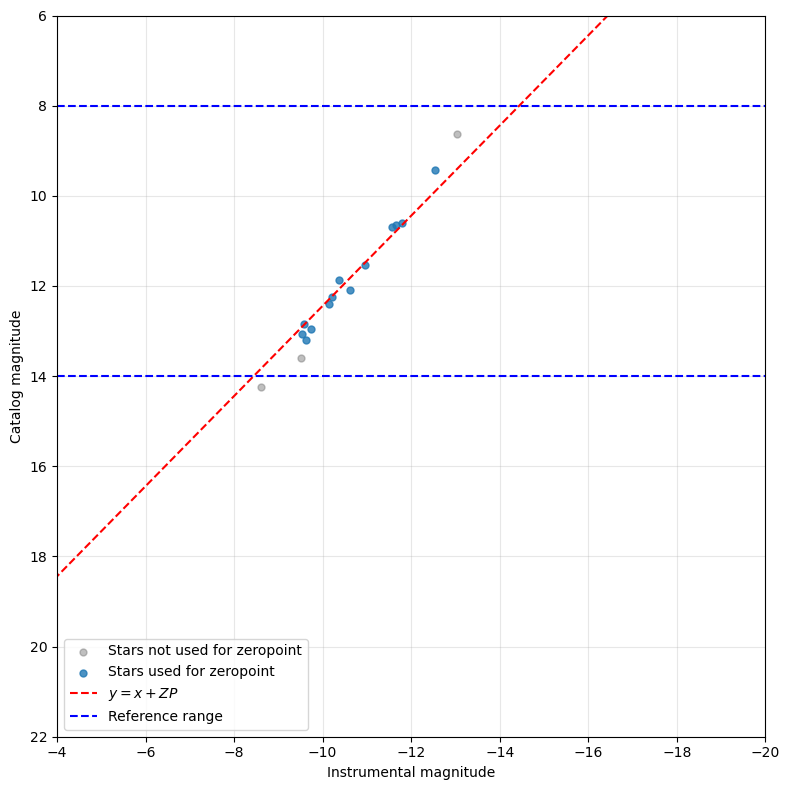

In [37]:
x = instrumental_mag[positive_flux]
y = catalog_mag[positive_flux]

# positive flux
used = np.asarray(
    rdls_phot["used_for_zeropoint"],
    dtype=bool,
)[positive_flux]

plt.figure(figsize=(8, 8))

# stars not used for zeropoint estimation
plt.scatter(
    x[~used],
    y[~used],
    s=25,
    color="gray",
    alpha=0.5,
    label="Stars not used for zeropoint",
)

# stars used for zeropoint estimation
plt.scatter(
    x[used],
    y[used],
    s=25,
    alpha=0.8,
    label="Stars used for zeropoint",
)

# y = x + magzero
x_line = np.linspace(-20, 20, 200)
y_line = x_line + photometric_zeropoint

plt.plot(
    x_line,
    y_line,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        rf"$y=x+ZP$"
    ),
)

plt.axhline(reference_mag_min,color="blue",linestyle="--",label="Reference range")
plt.axhline(reference_mag_max,color="blue",linestyle="--")

plt.xlabel("Instrumental magnitude")
plt.ylabel("Catalog magnitude")

plt.xlim([-20, -4])
plt.ylim([6, 22])

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Debug purpose
**Image plot**

In [38]:
# # scaling
# norm = ImageNormalize(
#     img_data,
#     interval=ZScaleInterval(),
#     stretch=AsinhStretch(),
# )

# fig, ax = plt.subplots(figsize=(12, 10))

# ax.imshow(
#     img_data,
#     origin="lower",
#     cmap="gray",
#     norm=norm,
# )

# for row in rdls_phot:
#     x = float(row["x_refined"])
#     y = float(row["y_refined"])
#     mag = float(row["mag"])

#     if not (
#         np.isfinite(x)
#         and np.isfinite(y)
#         and np.isfinite(mag)
#     ):
#         continue

#     circle = plt.Circle(
#         (x, y),
#         radius=8,
#         fill=False,
#         linewidth=1,
#     )
#     ax.add_patch(circle)

#     ax.annotate(
#         f"{mag:.2f}",
#         xy=(x, y),
#         xytext=(8, 8),
#         textcoords="offset points",
#         fontsize=8,
#         ha="left",
#         va="bottom",
#         bbox={
#             "facecolor": "black",
#             "alpha": 0.5,
#             "edgecolor": "none",
#             "pad": 1.5,
#         },
#     )

# ax.set_xlabel("X [pixel]")
# ax.set_ylabel("Y [pixel]")
# ax.set_title("Catalog magnitudes of stars")

# plt.tight_layout()
# plt.show()

**Aperture plot**

In [39]:
# x0 = float(rdls_phot["x_refined"][8])
# y0 = float(rdls_phot["y_refined"][8])

# yy, xx = np.indices(img_data.shape)
# radius = np.sqrt((xx - x0)**2 + (yy - y0)**2)

# r_bins = np.arange(0, 40, 1)

# radial_profile = []
# r_centers = []

# for r1, r2 in zip(r_bins[:-1], r_bins[1:]):
#     mask = (radius >= r1) & (radius < r2)

#     radial_profile.append(
#         np.nanmedian(img_data[mask])
#     )
#     r_centers.append((r1 + r2) / 2)

# plt.figure(figsize=(7, 5))
# plt.plot(r_centers, radial_profile, marker="o")

# plt.axvline(
#     aperture_radius,
#     linestyle="--",
#     label="Aperture radius",
# )

# plt.axvline(
#     annulus_r_in,
#     linestyle="--",
#     label="Annulus inner radius",
# )

# plt.axvline(
#     annulus_r_out,
#     linestyle="--",
#     label="Annulus outer radius",
# )

# plt.xlabel("Radius [pixel]")
# plt.ylabel("Median pixel value")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()